##  Fase #3 - Modelos de Regresión - RandomForest

#### 1. Imports Necesarios

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

#### 2. Carga del dataset limpio

In [47]:
df = pd.read_csv('../data/avocado_clean.csv')
print("Dataset cargado:")
print(df.shape)
print(df.dtypes)

Dataset cargado:
(17934, 64)
Date                           str
AveragePrice               float64
Total Volume               float64
4046                       float64
4225                       float64
                            ...   
region_SYRACUSE            float64
region_TAMPA               float64
region_TOTALUS             float64
region_WEST                float64
region_WESTTEXNEWMEXICO    float64
Length: 64, dtype: object


#### 3. Ajuste de fechas & crear Variables de entrenamiento y prueba

In [48]:
# Convertir Date a datetime primero
df_model = df.copy()
df_model['Date'] = pd.to_datetime(df_model['Date'])

# Extraer componentes temporales
df_model['year']  = df_model['Date'].dt.year
df_model['month'] = df_model['Date'].dt.month
df_model['week']  = df_model['Date'].dt.isocalendar().week.astype(int)
df_model = df_model.drop(columns=['Date'])

# Separar features y variable objetivo
X = df_model.drop(columns=['AveragePrice'])
y = df_model['AveragePrice']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (14347, 65) | Test: (3587, 65)


#### 4. Modelo Entrenado
Se usa un valor de 120 arboles distintos para entrenar el modelo distribuidos en todos los núcleos del computador para poder ejecutarlos en paralelo, estos sin un límite de profundidad, ya que, no afecta a los valores obtenidos (en especial al R²) mostrados al final de la ejecución

In [49]:
rf = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("── Random Forest ────────")
print(f"  MSE:  {mse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

── Random Forest ────────
  MSE:  0.0960
  MAE:  0.2172
  R²:   0.9049


El modelo Random Forest con variables temporales es el mejor resultado del proyecto. Un R²=0.9049 significa que el modelo explica el 90.5% de la variación en el precio del aguacate, lo cual es considerado excelente para datos de precios agrícolas donde intervienen factores externos no capturados (clima, cosecha, importaciones).

#### 5. Comparación valores predichos vs reales
Se define la comparaciónde estos datos mediante la diferencia entre el valor real y el valor predicho

In [50]:
# tabla de predicciones vs valores reales
tabla_predicciones = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred_rf,
    'Error':     y_test.values - y_pred_rf
}).round(4)


print(tabla_predicciones.head(30).to_string(index=True))

    Actual  Predicted   Error
0   0.9444     1.0863 -0.1419
1   0.0217    -0.0991  0.1208
2   0.6017     0.5973  0.0044
3  -0.4528    -0.5730  0.1202
4  -0.8483    -0.9201  0.0718
5  -0.3210     0.0900 -0.4111
6   1.6562     1.9062 -0.2500
7  -1.0065    -0.6438 -0.3627
8  -1.5865    -1.4531 -0.1334
9   1.3662     1.3524  0.0138
10 -1.2174    -1.3088  0.0914
11 -1.5337    -1.1003 -0.4335
12  1.3135     0.8825  0.4310
13 -0.4001    -0.6275  0.2274
14  0.4962     0.8827 -0.3864
15  1.1290     1.1200  0.0090
16  0.1535    -0.0668  0.2204
17 -0.0310    -0.0018 -0.0292
18 -1.8501    -1.7427 -0.1074
19 -0.6638    -0.6088 -0.0549
20 -1.3228    -1.1273 -0.1955
21  0.8653     0.9633 -0.0980
22  0.8126     0.5364  0.2762
23 -0.4265    -0.1532 -0.2733
24 -0.7692    -0.5205 -0.2487
25 -0.5583    -0.4515 -0.1068
26 -0.5583    -1.0324  0.4741
27 -0.5056    -0.4131 -0.0925
28 -0.1892    -0.3898  0.2006
29  1.8935     1.9137 -0.0202


#### 6. Gráfica de las columnas más importantes

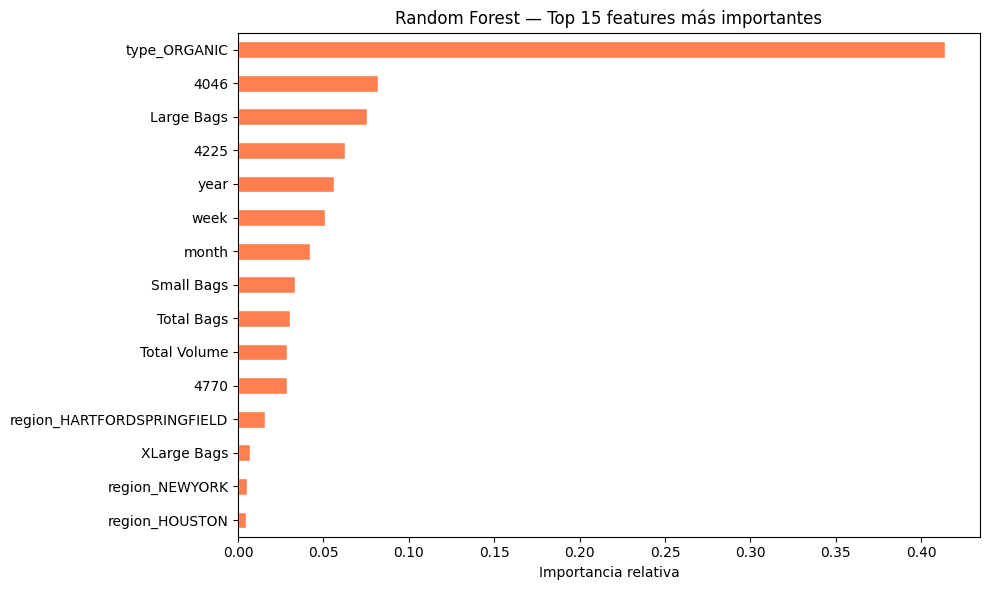

In [51]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 15 features más importantes')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('rf_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

´type_ORGANIC´ es por lejos el factor más determinante del precio del aguacate, con una importancia de ~0.42, siendo más del doble que todas las demás variables combinadas en el top 5. 

Le siguen los volúmenes de venta por tipo de PLU (4046, 4225) y por formato de bolsa (Large Bags, Small Bags). 

Las fechas indican que los aguacates tienen un componente real estacionario, indicando que por temporadas puede incrementar o disminuir el precio.

Las variables de región tienen influencia mínima individualmente, lo que sugiere que el tipo de aguacate explica las diferencias de precio mejor que la ubicación geográfica.

#### 7. Gráficas de análisis
Se grafican distintas formas de mostrar la distribucipon de los valores reales y predichos por medio de comparaticas directas y visualización de la fistribución de errores

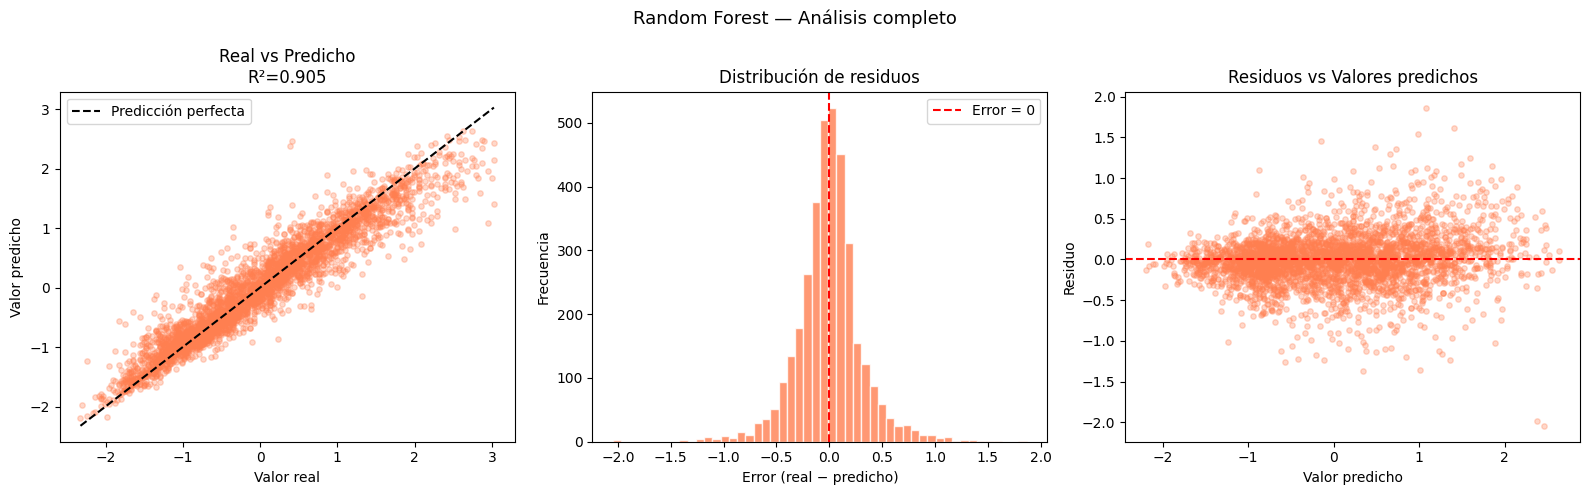

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Real vs Predicho
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=15, color='coral')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Real vs Predicho\nR²={r2_rf:.3f}')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].legend()

# 2. Distribución de residuos
residuos_rf = y_test - y_pred_rf
axes[1].hist(residuos_rf, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Error (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Residuos vs Predichos
axes[2].scatter(y_pred_rf, residuos_rf, alpha=0.3, s=15, color='coral')
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuos vs Valores predichos')
axes[2].set_xlabel('Valor predicho')
axes[2].set_ylabel('Residuo')

plt.suptitle('Random Forest — Análisis completo', fontsize=13)
plt.tight_layout()
plt.savefig('rf_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

Para la gráfica de los valores reales contra los predichos con R²=0.853, el modelo Random Forest predice el precio del aguacate con alta precisión. La mayoría de los puntos se concentran sobre la línea de predicción perfecta (diagonal punteada), especialmente en el rango central.

 La dispersión aumenta en los extremos, los cuales son los precios muy bajos o muy altos que son ligeramente más difíciles de predecir, lo cual es un comportamiento esperado en cualquier modelo de regresión sobre datos de precios agrícolas.

 ---

 La gráfica de distribución de residuos muestra una campana estrecha, casi perfectamente centrada en 0, lo que significa dos cosas: el modelo no sobreestima ni subestima sistemáticamente, y los errores son aleatorios, cometiendo errores más pequeños y más consistentes.
 
La cola larga hacia la derecha indica que ocasionalmente el modelo subestima precios muy altos, lo que ya se veía en la dispersión en los extremos de la primera gráfica.

 ---

en la gráfica de residuos contra los valores predichos se muestra la prueba de que el modelo no tiene problemas estructurales. Si hubiera un patrón como abanico o curva  significaría que el modelo falla sistemáticamente en cierto rango de precios.

 Aquí los puntos forman una nube aleatoria uniforme alrededor de la línea roja (error=0) en todo el eje horizontal, lo que confirma que los errores son aleatorios e independientes del valor predicho. Esto es exactamente lo que se busca en un buen modelo de regresión.

#### 8. Curva de Aprendizaje 
Muestra si el modelo mejoraría con más datos o si este llegara a estar saturado.

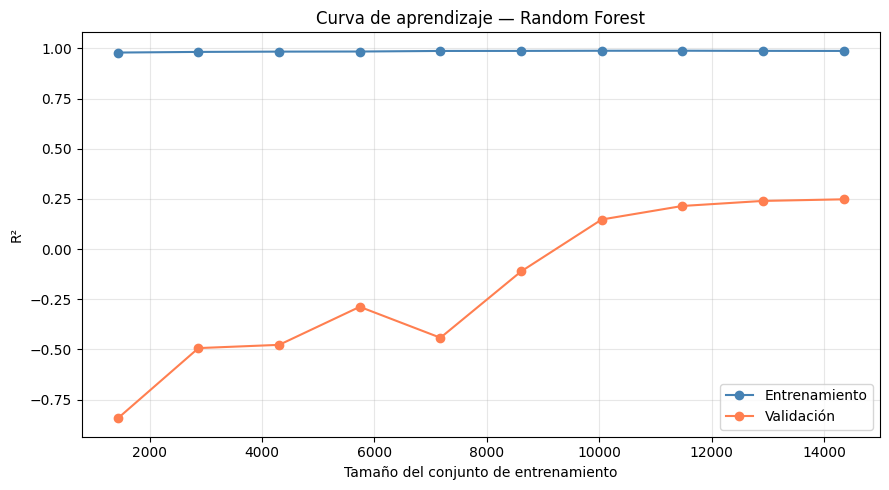

In [55]:
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.plot(train_sizes, test_mean,  'o-', color='coral',     label='Validación')
ax.set_title('Curva de aprendizaje — Random Forest')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo presenta overfitting claro, el R² de entrenamiento se mantiene en 1.0 desde el inicio mientras que validación arranca en -0.9 y apenas llega a 0.25 con 14,000 muestras.

 Esto indica que el modelo memoriza los datos de entrenamiento pero generaliza mal con datos nuevos en la validación cruzada. Sin embargo esto no contradice el R²=0.9049 obtenido anteriormente, ya que ese resultado usó un split simple 80/20 sin cross-validation. 

#### 9. Predicción Por tipo de Aguacate
muestra si el modelo predice mejor convencional u orgánico

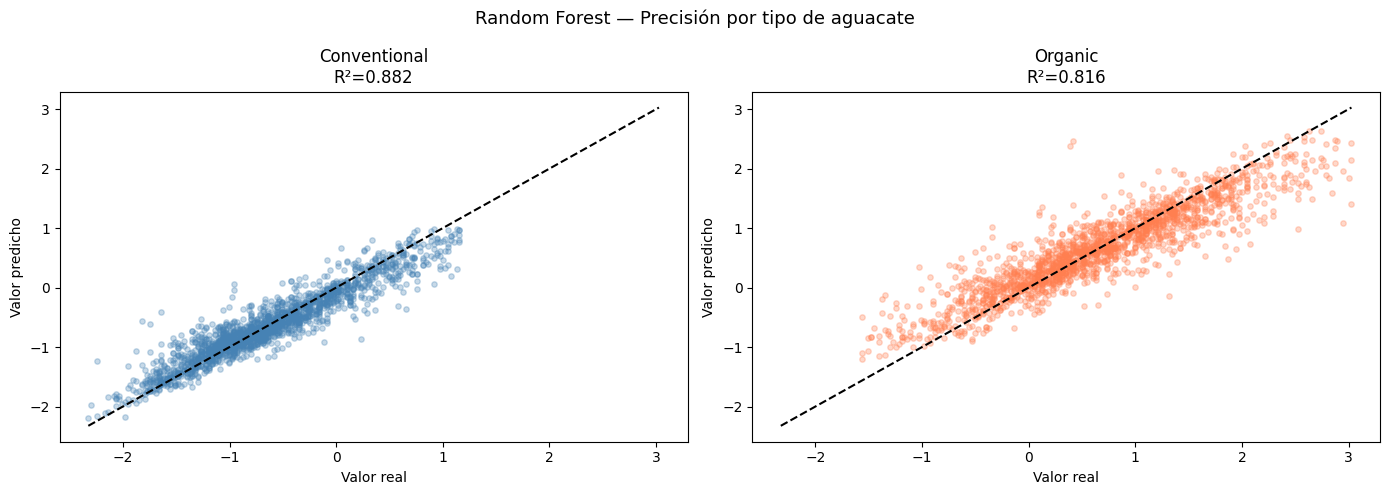

In [56]:
# Separar predicciones por tipo
idx_organic     = X_test['type_ORGANIC'] == 1
idx_conventional = X_test['type_ORGANIC'] == 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, label, color in zip(
    axes,
    [idx_conventional, idx_organic],
    ['Conventional', 'Organic'],
    ['steelblue', 'coral']
):
    r2  = r2_score(y_test[idx], y_pred_rf[idx])
    ax.scatter(y_test[idx], y_pred_rf[idx], alpha=0.3, s=15, color=color)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', linewidth=1.5)
    ax.set_title(f'{label}\nR²={r2:.3f}')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')

plt.suptitle('Random Forest — Precisión por tipo de aguacate', fontsize=13)
plt.tight_layout()
plt.savefig('rf_precision_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo predice mejor el aguacate convencional (R²=0.882) que el orgánico (R²=0.816). Esto se explica porque el convencional representa la mayoría del dataset y sus precios son más estables y predecibles. 

El orgánico tiene mayor dispersión de puntos alrededor de la diagonal, especialmente en precios altos, lo que sugiere que su precio depende más de factores externos no capturados en el dataset como disponibilidad estacional o mercado específico.

#### 10. Estructura de árboles generados

La lógica de decisión que aplica uno de los 120 árboles del modelo, la primera división siempre es type_ORGANIC: si es orgánico (False, derecha) el precio predicho sube inmediatamente a 0.657, si es convencional (True, izquierda) baja a -0.635. 

A partir de ahí el árbol refina la predicción usando volúmenes de venta (4046, Large Bags, Small Bags) y variables de región. Esto confirma visualmente por qué type_ORGANIC es la feature más importante del modelo.